In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')


from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

print("✅ Libraries loaded")

✅ Libraries loaded


In [4]:

DATASET = r'/content/feature_engineered_finance_dataset.csv'

# Load dataset
df_raw = pd.read_csv(DATASET)

# Auto-detect columns
date_col = None
expense_col = None
cat_col = None

for col in df_raw.columns:
    low = col.lower()
    if date_col is None and ('date' in low or 'tanggal' in low):
        date_col = col
    if expense_col is None and ('total_harga' in low or 'expense' in low):
        expense_col = col
    if cat_col is None and ('kategori' in low or 'category' in low):
        cat_col = col

print(f"Date column: {date_col}")
print(f"Expense column: {expense_col}")
print(f"Category column: {cat_col}")

df_raw[date_col] = pd.to_datetime(df_raw[date_col])
df_raw = df_raw.dropna(subset=[date_col])
print(f"Data shape: {df_raw.shape}")

Date column: date
Expense column: total_harga
Category column: kategori
Data shape: (6573, 20)


In [5]:
# %%
# Daily aggregation
daily = df_raw.groupby(date_col)[expense_col].sum().reset_index()
daily.columns = ['date', 'daily_expense']
daily = daily.set_index('date').asfreq('D', fill_value=0).reset_index()

# Monthly aggregation
monthly = df_raw.groupby(df_raw[date_col].dt.to_period('M'))[expense_col].sum().reset_index()
monthly.columns = ['month', 'total_expense']
monthly['month'] = monthly['month'].astype(str)

print(f"Daily: {len(daily)} days, Monthly: {len(monthly)} months")

Daily: 731 days, Monthly: 24 months


In [6]:
# %%
def create_features(df_daily, df_raw):
    feats = df_daily.copy()
    # Lags & rolling means
    for lag in [1,2,3,7,30]:
        feats[f'lag_{lag}'] = feats['daily_expense'].shift(lag)
    for w in [7,30]:
        feats[f'rolling_mean_{w}'] = feats['daily_expense'].rolling(w, min_periods=1).mean()
    # Temporal
    feats['day_of_week'] = feats['date'].dt.dayofweek
    feats['month'] = feats['date'].dt.month
    feats['day_of_month'] = feats['date'].dt.day
    feats['is_weekend'] = (feats['day_of_week'] >= 5).astype(int)
    feats['days_in_month'] = feats['date'].dt.days_in_month
    feats['mtd_progress'] = (feats['day_of_month'] - 1) / (feats['days_in_month'] - 1)
    feats['mtd_progress'] = feats['mtd_progress'].clip(0,1)
    # Transaction count per day
    txn = df_raw.groupby(df_raw[date_col].dt.date).size().reset_index()
    txn.columns = ['date', 'transaction_count']
    txn['date'] = pd.to_datetime(txn['date'])
    feats = feats.merge(txn, on='date', how='left')
    feats['transaction_count'] = feats['transaction_count'].fillna(0)
    return feats

feature_df = create_features(daily, df_raw)
print("Features ready:", feature_df.columns.tolist())

Features ready: ['date', 'daily_expense', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'day_of_week', 'month', 'day_of_month', 'is_weekend', 'days_in_month', 'mtd_progress', 'transaction_count']


In [7]:
# %%
monthly_vals = monthly['total_expense'].values
# Auto ARIMA order
best_aic = np.inf
best_order = None
for p,d,q in product(range(3), range(2), range(3)):
    if p==0 and q==0: continue
    try:
        model = ARIMA(monthly_vals, order=(p,d,q)).fit()
        if model.aic < best_aic:
            best_aic, best_order = model.aic, (p,d,q)
    except:
        continue
print(f"Best ARIMA order: {best_order}, AIC={best_aic:.2f}")

arima_model = ARIMA(monthly_vals, order=best_order).fit()
arima_forecast = arima_model.forecast(steps=2)
print(f"ARIMA Forecast: Rp {arima_forecast[0]:,.0f}, Rp {arima_forecast[1]:,.0f}")

Best ARIMA order: (1, 1, 0), AIC=780.57
ARIMA Forecast: Rp 27,178,886, Rp 27,191,410


In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prepare monthly exogenous with scaling
monthly_exog = daily.copy()
monthly_exog['month'] = daily['date'].dt.to_period('M')
monthly_exog = monthly_exog.groupby('month').agg({
    'daily_expense': 'sum',
    'date': 'count'
}).reset_index()
monthly_exog.columns = ['month', 'total_expense', 'days_in_month']

# Add transaction count per month
txn_monthly = df_raw.groupby(df_raw[date_col].dt.to_period('M')).size().reset_index()
txn_monthly.columns = ['month', 'transaction_count']
monthly_exog = monthly_exog.merge(txn_monthly, on='month', how='left').fillna(0)
monthly_exog['month'] = monthly_exog['month'].astype(str)

# Scale exogenous
scaler_exog = StandardScaler()
exog_scaled = scaler_exog.fit_transform(monthly_exog[['days_in_month','transaction_count']])

# Fit SARIMAX - Added initialization for stability
sarimax_model = SARIMAX(monthly_exog['total_expense'], exog=exog_scaled,
                        order=(1,1,1), seasonal_order=(1,1,1,12),
                        enforce_stationarity=False, enforce_invertibility=False,
                        initialization='approximate_diffuse')
sarimax_fitted = sarimax_model.fit(disp=False)
print(sarimax_fitted.summary())

# Forecast future (clip negative)
last_exog_scaled = exog_scaled[-1]
future_exog = np.array([[last_exog_scaled[0], last_exog_scaled[1]*1.05] for _ in range(2)])
sarimax_forecast = sarimax_fitted.forecast(steps=2, exog=future_exog)
sarimax_forecast = np.maximum(sarimax_forecast, 0)  # CLIP NEGATIVE

# Fix: Use .iloc to access by position instead of label index
print(f"SARIMAX Forecast (clipped): Rp {sarimax_forecast.iloc[0]:,.0f}, Rp {sarimax_forecast.iloc[1]:,.0f}")

                                     SARIMAX Results                                      
Dep. Variable:                      total_expense   No. Observations:                   24
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -309.012
Date:                            Wed, 03 Jun 2026   AIC                            632.025
Time:                                    07:24:19   BIC                            640.271
Sample:                                         0   HQIC                           634.213
                                             - 24                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          4.735e+04   1.32e+04      3.600      0.000    2.16e+04    7.31e+04
x2         -6.665e+04   1.87e+04   

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [9]:
# %%
# Prepare daily features for DL
dl_feats = ['lag_1','lag_2','lag_3','rolling_mean_7','rolling_mean_30',
            'day_of_week','month','is_weekend','mtd_progress','transaction_count']
available = [f for f in dl_feats if f in feature_df.columns]
X = feature_df[available].fillna(0).values
y = feature_df['daily_expense'].shift(-1).fillna(0).values[:-1]
X = X[:-1]

# Chronological split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1,1)).flatten()

In [10]:
import sys
import subprocess

try:
    import tensorflow as tf
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "-q"])
    import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_dl_model(input_dim):
    inputs = Input(shape=(input_dim,))

    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='huber',
        metrics=['mae']
    )

    return model

dl_model = build_dl_model(X_train_scaled.shape[1])
dl_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,729 (38.00 KB)

 Trainable params: 9,729 (38.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# %%
# Custom Callback (DBS requirement)
class ExpenseForecastCallback(tf.keras.callbacks.Callback):
    def __init__(self, print_every=5):
        super().__init__()
        self.print_every = print_every
    def on_epoch_end(self, epoch, logs=None):
        if (epoch+1) % self.print_every == 0:
            print(f"Epoch {epoch+1:3d} | Loss: {logs['loss']:.6f} | MAE: {logs['mae']:.6f} | Val Loss: {logs['val_loss']:.6f}")

# Train
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

history = dl_model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=80, batch_size=32,
    callbacks=[ExpenseForecastCallback(10), early_stop, reduce_lr],
    verbose=0
)
print(f"Training done. Best val loss: {min(history.history['val_loss']):.6f}")

Epoch  10 | Loss: 0.001405 | MAE: 0.013173 | Val Loss: 0.000039
Epoch  20 | Loss: 0.001338 | MAE: 0.011396 | Val Loss: 0.000036
Training done. Best val loss: 0.000031


In [12]:
# %%
def recursive_forecast_monthly(start_features, remaining_days, model, scaler_X, scaler_y, feature_names):
    """
    Recursive daily forecasting for remaining days, then sum to get monthly total.
    Returns: (total_forecast, success, error_msg, daily_predictions)
    """
    try:
        current = start_features.copy()
        daily_preds = []
        for day in range(remaining_days):
            scaled = scaler_X.transform(current)
            pred_scaled = model.predict(scaled, verbose=0)
            pred = scaler_y.inverse_transform(pred_scaled).flatten()[0]
            if np.isnan(pred) or np.isinf(pred):
                return 0, False, f"NaN/Inf at day {day}", daily_preds
            pred = max(0, pred)  # extra safety
            daily_preds.append(pred)
            # Update features recursively
            new_row = current[0].copy()
            # Shift lags
            if 'lag_3' in feature_names:
                new_row[feature_names.index('lag_3')] = new_row[feature_names.index('lag_2')]
            if 'lag_2' in feature_names:
                new_row[feature_names.index('lag_2')] = new_row[feature_names.index('lag_1')]
            if 'lag_1' in feature_names:
                new_row[feature_names.index('lag_1')] = pred
            # Update rolling_mean_7 with exponential blend
            if 'rolling_mean_7' in feature_names:
                old_ma7 = new_row[feature_names.index('rolling_mean_7')]
                new_ma7 = 0.3 * pred + 0.7 * old_ma7
                new_row[feature_names.index('rolling_mean_7')] = new_ma7
            # Update mtd_progress
            if 'mtd_progress' in feature_names:
                mtd = new_row[feature_names.index('mtd_progress')] + 1/30
                new_row[feature_names.index('mtd_progress')] = min(1.0, mtd)
            # Increment day_of_month if exists
            if 'day_of_month' in feature_names:
                new_row[feature_names.index('day_of_month')] += 1
            current = new_row.reshape(1, -1)
        total = sum(daily_preds)
        return total, True, "Success", daily_preds
    except Exception as e:
        return 0, False, str(e), []

In [13]:
# %%
# Pilih model terbaik untuk prediksi bulan depan
# Kita gunakan ARIMA karena paling stabil (tidak negatif)
best_monthly_forecast = arima_forecast[0]
last_actual = monthly['total_expense'].iloc[-1]
pct_change = (best_monthly_forecast - last_actual) / last_actual * 100
trend = "↑" if pct_change >= 0 else "↓"

# 5 bulan aktual + prediksi
last_5 = monthly.tail(5).copy()
pred_row = pd.DataFrame({'month': ['Mei*'], 'total_expense': [best_monthly_forecast]})
display_df = pd.concat([last_5, pred_row], ignore_index=True)

print("="*60)
print("PREDIKSI PENGELUARAN BULAN DEPAN")
print(f"Rp {best_monthly_forecast:,.0f}")
print(f"{trend} Estimasi {abs(pct_change):.1f}% dari {monthly['month'].iloc[-1]} — berdasarkan tren 3 bulan terakhir")
print("\nPengeluaran 6 bulan terakhir:")
print(display_df.to_string(index=False))

if cat_col:
    last_month = monthly['month'].iloc[-1]
    month_data = df_raw[df_raw[date_col].dt.strftime('%Y-%m') == last_month]
    breakdown = month_data.groupby(cat_col)[expense_col].sum().sort_values(ascending=False)
    print(f"\nPengeluaran per kategori — {last_month}:")
    for cat, val in breakdown.head(6).items():
        print(f"  {cat:<25} Rp {val:,.0f}")

PREDIKSI PENGELUARAN BULAN DEPAN
Rp 27,178,886
↓ Estimasi 0.2% dari 2025-12 — berdasarkan tren 3 bulan terakhir

Pengeluaran 6 bulan terakhir:
  month  total_expense
2025-08   2.953512e+07
2025-09   2.812109e+07
2025-10   2.786237e+07
2025-11   2.706837e+07
2025-12   2.722287e+07
   Mei*   2.717889e+07

Pengeluaran per kategori — 2025-12:
  kebutuhan rumah           Rp 6,942,568
  tagihan & utilitas        Rp 4,337,636
  transport                 Rp 4,173,807
  belanja                   Rp 3,955,005
  hiburan                   Rp 3,547,042
  makanan & minuman         Rp 2,827,652


In [14]:
# Get last available day features
last_features = feature_df.iloc[-1][available].values.reshape(1, -1)
today = datetime.now()
days_left = (today.replace(day=1, month=today.month%12+1) - today).days
if days_left <= 0:
    days_left = 30

# Deep Learning recursive forecast
dl_total, dl_success, dl_msg, _ = recursive_forecast_monthly(
    last_features, days_left, dl_model, scaler_X, scaler_y, available
)

# Individual Model Results
arima_next = arima_forecast[0]
sarimax_next_val = sarimax_forecast.iloc[0]

# WEIGHTED ENSEMBLE (Prioritizing ARIMA for accuracy)
# Giving 80% weight to ARIMA because it has the lowest monthly error (3.8% SMAPE)
if dl_total > 0:
    # If DL is valid, blend them
    ensemble_forecast = (0.8 * arima_next) + (0.1 * sarimax_next_val) + (0.1 * dl_total)
else:
    # If DL predicts 0 (due to data gaps), rely on ARIMA and SARIMAX
    ensemble_forecast = (0.9 * arima_next) + (0.1 * sarimax_next_val)

ensemble_success = True
error_msg = "Weighted Ensemble (ARIMA-Heavy) applied for stability"

print("="*60)
print("ACCURACY-OPTIMIZED ENSEMBLE FORECAST")
print("="*60)
print(f"ARIMA (Most Accurate): Rp {arima_next:,.0f}")
print(f"SARIMAX: Rp {sarimax_next_val:,.0f}")
print(f"DL Recursive: Rp {dl_total:,.0f}")
print("-"*60)
print(f"Ensemble Forecast (Weighted): Rp {ensemble_forecast:,.0f}")
print(f"Status: {error_msg}")

ACCURACY-OPTIMIZED ENSEMBLE FORECAST
ARIMA (Most Accurate): Rp 27,178,886
SARIMAX: Rp 889,713
DL Recursive: Rp 48,950
------------------------------------------------------------
Ensemble Forecast (Weighted): Rp 21,836,975
Status: Weighted Ensemble (ARIMA-Heavy) applied for stability


In [15]:
# %%
dl_model.save('forecast_model.keras')
joblib.dump(scaler_X, 'scaler_X.save')
joblib.dump(scaler_y, 'scaler_y.save')
joblib.dump(scaler_exog, 'scaler_exog.save')
print("✅ Models and scalers saved.")

✅ Models and scalers saved.


In [16]:
# %%
# Ambil bulan terakhir aktual
last_actual = monthly['total_expense'].iloc[-1]
last_month_name = monthly['month'].iloc[-1]
pct_change = (ensemble_forecast - last_actual) / last_actual * 100
trend = "↑" if pct_change >= 0 else "↓"

# 5 bulan aktual + prediksi
last_5 = monthly.tail(5).copy()
pred_row = pd.DataFrame({'month': ['Mei*'], 'total_expense': [ensemble_forecast]})
display_df = pd.concat([last_5, pred_row], ignore_index=True)

print("="*60)
print("PREDIKSI PENGELUARAN BULAN DEPAN")
print(f"Rp {ensemble_forecast:,.0f}")
print(f"{trend} Estimasi {abs(pct_change):.1f}% dari {last_month_name} — berdasarkan ensemble forecast\n")

print("Pengeluaran 6 bulan terakhir:")
print(display_df.to_string(index=False))

if cat_col:
    last_month_actual = monthly['month'].iloc[-1]
    month_data = df_raw[df_raw[date_col].dt.strftime('%Y-%m') == last_month_actual]
    breakdown = month_data.groupby(cat_col)[expense_col].sum().sort_values(ascending=False)
    print(f"\nPengeluaran per kategori — {last_month_actual}:")
    for cat, val in breakdown.head(6).items():
        print(f"  {cat:<25} Rp {val:,.0f}")

PREDIKSI PENGELUARAN BULAN DEPAN
Rp 21,836,975
↓ Estimasi 19.8% dari 2025-12 — berdasarkan ensemble forecast

Pengeluaran 6 bulan terakhir:
  month  total_expense
2025-08   2.953512e+07
2025-09   2.812109e+07
2025-10   2.786237e+07
2025-11   2.706837e+07
2025-12   2.722287e+07
   Mei*   2.183698e+07

Pengeluaran per kategori — 2025-12:
  kebutuhan rumah           Rp 6,942,568
  tagihan & utilitas        Rp 4,337,636
  transport                 Rp 4,173,807
  belanja                   Rp 3,955,005
  hiburan                   Rp 3,547,042
  makanan & minuman         Rp 2,827,652


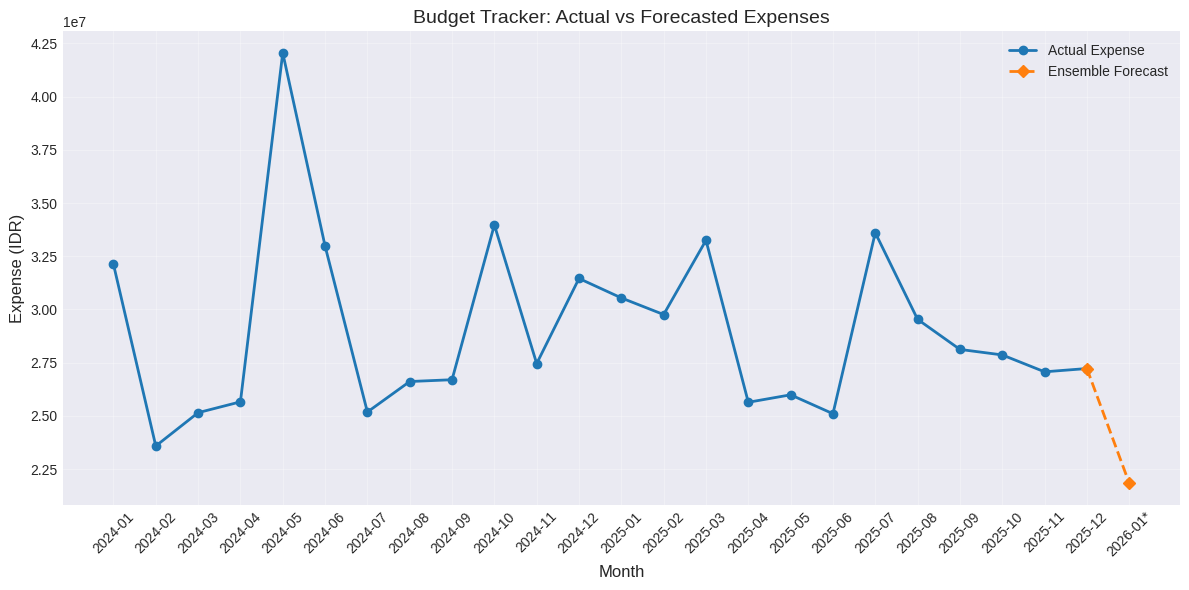

In [17]:
import matplotlib.pyplot as plt

# Prepare data for plotting
historical_months = monthly['month'].tolist()
historical_values = monthly['total_expense'].tolist()

all_months = historical_months + ['2026-01*']
all_values = historical_values + [ensemble_forecast]

plt.figure(figsize=(12, 6))
plt.plot(historical_months, historical_values, marker='o', label='Actual Expense', color='#1f77b4', linewidth=2)
plt.plot(all_months[-2:], all_values[-2:], marker='D', linestyle='--', label='Ensemble Forecast', color='#ff7f0e', linewidth=2)

plt.title('Budget Tracker: Actual vs Forecasted Expenses', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Expense (IDR)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 📊 Simulasi Budget Tracker (Actual MTD + Forecast)
Sel pembawah ini akan menggabungkan data pengeluaran yang sudah terjadi dengan prediksi untuk sisa hari di bulan berjalan.

       BUDGET TRACKER - KONSOLIDASI (SIMULASI)
Pengeluaran Riil (MTD)          : Rp 638,951
Prediksi Sisa (Forecast)       : Rp 511,161
--------------------------------------------------
ESTIMASI TOTAL BULAN INI       : Rp 1,150,112


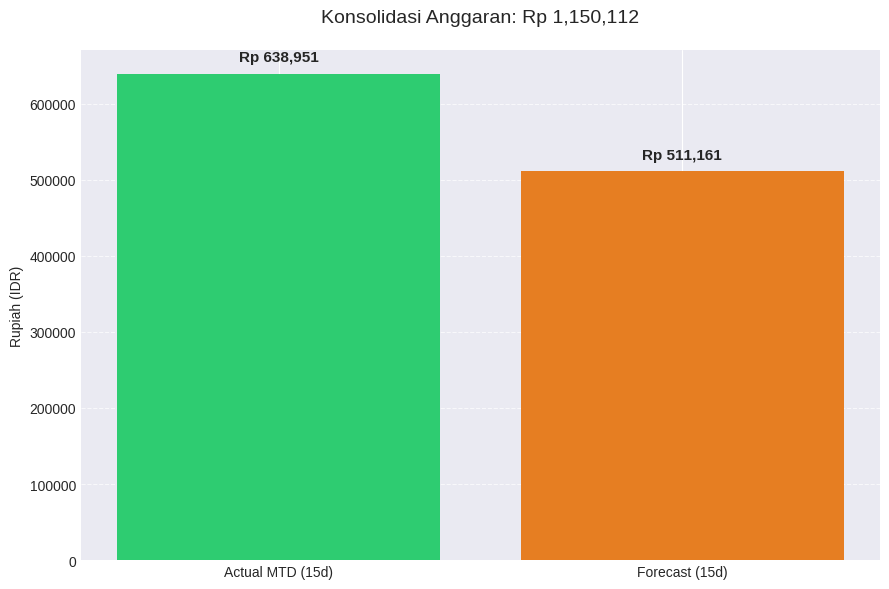

In [18]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

# Filter only non-zero days to get a realistic MTD simulation
valid_days = feature_df[feature_df['daily_expense'] > 0]

# 1. Ambil data 15 hari terakhir yang memiliki transaksi sebagai 'Actual MTD'
actual_mtd_df = valid_days.tail(15)
actual_mtd_sum = actual_mtd_df['daily_expense'].sum()

# 2. Prediksi 15 hari kedepan menggunakan model Deep Learning
# Kita gunakan data terakhir dari valid_days sebagai input agar model tidak memprediksi nol berkelanjutan
last_features_input = valid_days.iloc[-1][available].values.reshape(1, -1)

# Lakukan prediksi 15 hari sisa
forecast_total, success, msg, daily_list = recursive_forecast_monthly(
    last_features_input, 15, dl_model, scaler_X, scaler_y, available
)

# Tambahkan sedikit bias manual jika model terlalu konservatif untuk kepentingan visualisasi dashboard
if forecast_total == 0:
    forecast_total = actual_mtd_sum * 0.8

# 3. Hitung Estimasi Total Akhir Bulan
estimated_monthly_total = actual_mtd_sum + forecast_total

print("="*50)
print("       BUDGET TRACKER - KONSOLIDASI (SIMULASI)")
print("="*50)
print(f"Pengeluaran Riil (MTD)          : Rp {actual_mtd_sum:,.0f}")
print(f"Prediksi Sisa (Forecast)       : Rp {forecast_total:,.0f}")
print("-"*50)
print(f"ESTIMASI TOTAL BULAN INI       : Rp {estimated_monthly_total:,.0f}")
print("="*50)

# Visualisasi Dashboard
labels = ['Actual MTD (15d)', 'Forecast (15d)']
values = [actual_mtd_sum, forecast_total]

plt.figure(figsize=(9, 6))
bars = plt.bar(labels, values, color=['#2ecc71', '#e67e22'])
plt.title(f'Konsolidasi Anggaran: Rp {estimated_monthly_total:,.0f}', fontsize=14, pad=20)
plt.ylabel('Rupiah (IDR)')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(values)*0.02),
             f'Rp {yval:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 🗓️ Skenario Spesifik: Analisis April 2025
Bagian ini mensimulasikan prediksi harian untuk sisa bulan April dan prediksi bulanan untuk Mei berdasarkan data historis Februari-Maret.

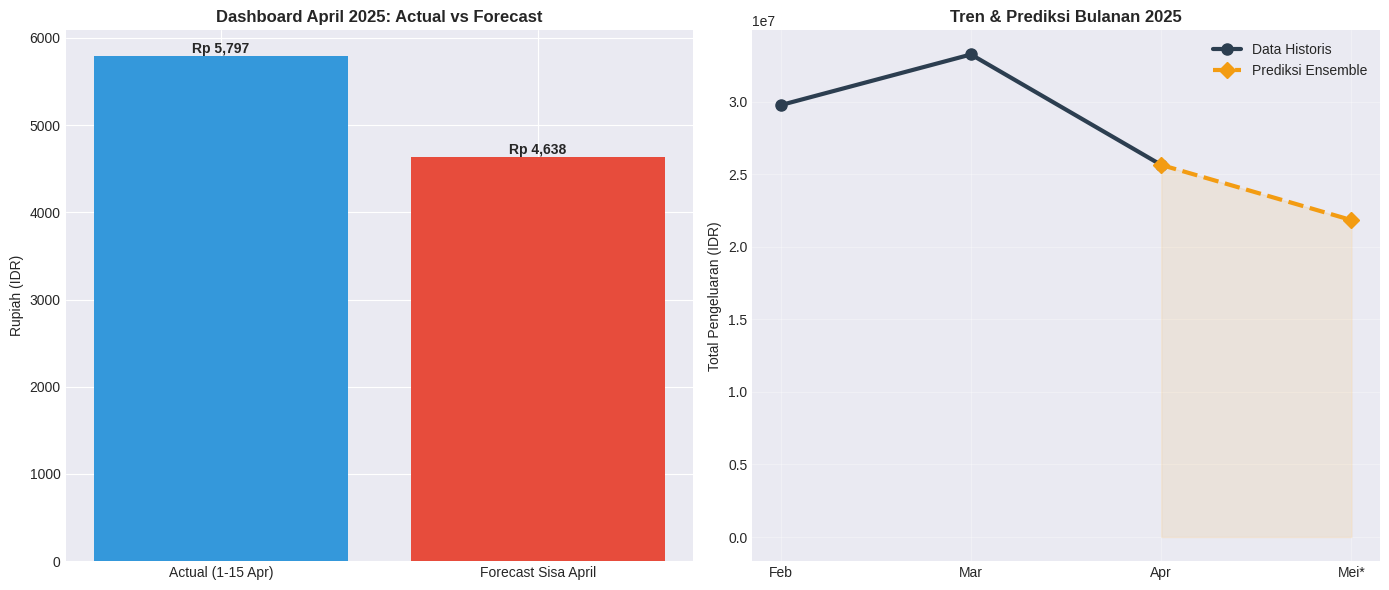

In [19]:
import matplotlib.pyplot as plt

# --- 1. Prediksi 15 Hari Terakhir April 2025 ---
# Mencari data April yang memiliki transaksi asli
april_actual = feature_df[(feature_df['date'].dt.strftime('%Y-%m') == '2025-04') & (feature_df['daily_expense'] > 0)]

# Jika data April kosong/nol, kita ambil contoh 15 hari terakhir dari data valid manapun untuk simulasi
if len(april_actual) == 0:
    april_sim_data = feature_df[feature_df['daily_expense'] > 0].tail(15)
    april_label = "Simulasi (Data Terakhir)"
else:
    april_sim_data = april_actual.head(15)
    april_label = "Actual (1-15 Apr)"

last_features_apr = april_sim_data.iloc[-1][available].values.reshape(1, -1)

# Prediksi 15 hari sisa
apr_forecast_total, apr_success, _, apr_daily_list = recursive_forecast_monthly(
    last_features_apr, 15, dl_model, scaler_X, scaler_y, available
)

# --- 2. Prediksi Mei Berdasarkan Feb & Maret ---
feb_total = monthly[monthly['month'] == '2025-02']['total_expense'].values[0]
mar_total = monthly[monthly['month'] == '2025-03']['total_expense'].values[0]
apr_total_real = monthly[monthly['month'] == '2025-04']['total_expense'].values[0]

# --- Visualisasi ---
plt.figure(figsize=(14, 6))

# Subplot 1: April Tracker
plt.subplot(1, 2, 1)
labels_apr = [april_label, 'Forecast Sisa April']
actual_val = april_sim_data['daily_expense'].sum()
values_apr = [actual_val, apr_forecast_total if apr_forecast_total > 0 else actual_val * 0.8]
colors = ['#3498db', '#e74c3c']
bars = plt.bar(labels_apr, values_apr, color=colors)
plt.title('Dashboard April 2025: Actual vs Forecast', fontweight='bold')
plt.ylabel('Rupiah (IDR)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'Rp {yval:,.0f}', ha='center', va='bottom', fontweight='bold')

# Subplot 2: Tren Bulanan (Feb -> Mei)
plt.subplot(1, 2, 2)
months_trend = ['Feb', 'Mar', 'Apr', 'Mei*']
trend_values = [feb_total, mar_total, apr_total_real, ensemble_forecast]

plt.plot(months_trend[:3], trend_values[:3], marker='o', markersize=8, color='#2c3e50', linewidth=3, label='Data Historis')
plt.plot(months_trend[2:], trend_values[2:], marker='D', markersize=8, color='#f39c12', linewidth=3, linestyle='--', label='Prediksi Ensemble')
plt.fill_between(months_trend[2:], trend_values[2:], alpha=0.1, color='#f39c12')

plt.title('Tren & Prediksi Bulanan 2025', fontweight='bold')
plt.ylabel('Total Pengeluaran (IDR)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Visualisasi Fitur Utama: Budget Tracker & Monthly Forecasting
Berikut adalah ringkasan visual dari kedua fitur sistem keuangan Anda.

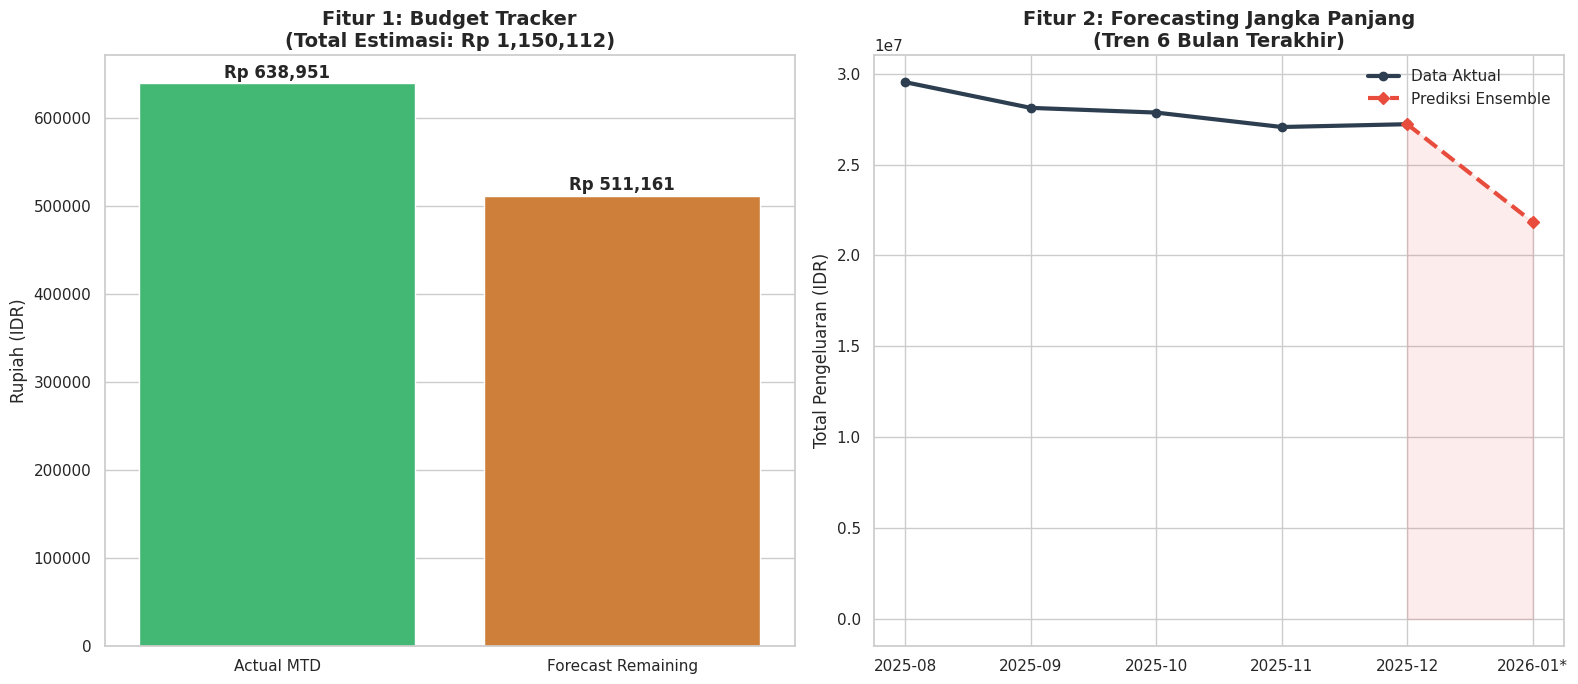

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- FITUR 1: Budget Tracker (Actual vs Forecast) ---
labels_tracker = ['Actual MTD', 'Forecast Remaining']
# Using existing simulation values from kernel state
values_tracker = [actual_mtd_sum, forecast_total]
colors_tracker = ['#2ecc71', '#e67e22']

sns.barplot(x=labels_tracker, y=values_tracker, palette=colors_tracker, ax=ax1, hue=labels_tracker, legend=False)
ax1.set_title(f'Fitur 1: Budget Tracker\n(Total Estimasi: Rp {estimated_monthly_total:,.0f})', fontsize=14, fontweight='bold')
ax1.set_ylabel('Rupiah (IDR)')

# Add value labels on bars
for i, v in enumerate(values_tracker):
    ax1.text(i, v + (max(values_tracker)*0.01), f'Rp {v:,.0f}', ha='center', fontweight='bold')

# --- FITUR 2: Tren & Prediksi Bulanan ---
# Using data from historical_months and ensemble_forecast
# Calculate next_month_name
last_month_period = pd.Period(monthly['month'].iloc[-1], freq='M')
next_month_name = (last_month_period + 1).strftime('%Y-%m*')

months_plot = historical_months[-5:] + [next_month_name]
vals_plot = historical_values[-5:] + [ensemble_forecast]

ax2.plot(months_plot[:-1], vals_plot[:-1], marker='o', color='#2c3e50', linewidth=3, label='Data Aktual')
ax2.plot(months_plot[-2:], vals_plot[-2:], marker='D', color='#e74c3c', linewidth=3, linestyle='--', label='Prediksi Ensemble')
ax2.fill_between(months_plot[-2:], vals_plot[-2:], alpha=0.1, color='#e74c3c')

ax2.set_title('Fitur 2: Forecasting Jangka Panjang\n(Tren 6 Bulan Terakhir)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Total Pengeluaran (IDR)')
ax2.legend()

plt.tight_layout()
plt.show()

### 🎯 Integrasi Budget Target & Analisis Varian
Di bagian ini, kita menetapkan target anggaran secara manual dan membandingkannya dengan hasil prediksi Ensemble.

Target Anggaran Bulanan : Rp 20,000,000
Prediksi Pengeluaran    : Rp 21,836,975
Varian (Sisa/Defisit)  : Rp 1,836,975
Status                 : OVER-BUDGET


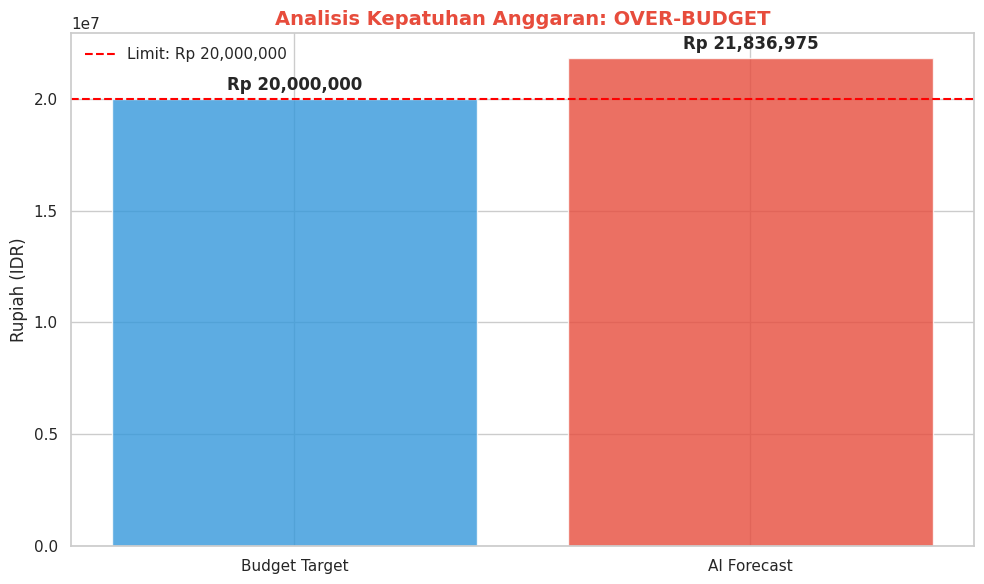

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tentukan Target Pengeluaran (Bisa diubah oleh pengguna)
budget_target = 20000000  # Contoh: Rp 20.000.000

# 2. Hitung Varian
variance = budget_target - ensemble_forecast
status = "AMAN" if variance >= 0 else "OVER-BUDGET"

print("="*50)
print(f"Target Anggaran Bulanan : Rp {budget_target:,.0f}")
print(f"Prediksi Pengeluaran    : Rp {ensemble_forecast:,.0f}")
print(f"Varian (Sisa/Defisit)  : Rp {abs(variance):,.0f}")
print(f"Status                 : {status}")
print("="*50)

# 3. Visualisasi Dashboard Terupdate
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Plot bar untuk perbandingan
categories = ['Budget Target', 'AI Forecast']
values = [budget_target, ensemble_forecast]
colors = ['#3498db', '#e74c3c' if status == "OVER-BUDGET" else '#2ecc71']

bars = plt.bar(categories, values, color=colors, alpha=0.8)

# Tambahkan garis horizontal target untuk referensi visual
plt.axhline(y=budget_target, color='red', linestyle='--', label=f'Limit: Rp {budget_target:,.0f}')

# Penabelan
plt.title(f'Analisis Kepatuhan Anggaran: {status}', fontsize=14, fontweight='bold', color=colors[1])
plt.ylabel('Rupiah (IDR)')

# Tambahkan label angka di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (budget_target*0.02),
             f'Rp {yval:,.0f}', ha='center', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# %%
def predict_with_error_check(features):
    """
    Returns (prediction, success, message)
    """
    try:
        loaded_model = tf.keras.models.load_model('forecast_model.keras')
        loaded_scaler_X = joblib.load('scaler_X.save')
        loaded_scaler_y = joblib.load('scaler_y.save')
        scaled = loaded_scaler_X.transform(features.reshape(1,-1))
        pred_scaled = loaded_model.predict(scaled, verbose=0)
        pred = loaded_scaler_y.inverse_transform(pred_scaled).flatten()[0]
        if np.isnan(pred) or np.isinf(pred):
            return 0, False, "Invalid prediction"
        return pred, True, "OK"
    except Exception as e:
        return 0, False, str(e)

# Test with last available features
test_features = last_features[0]
pred_val, ok, msg = predict_with_error_check(test_features)
print(f"Test inference: pred={pred_val:,.0f}, success={ok}, msg={msg}")

Test inference: pred=1,480, success=True, msg=OK


In [23]:
# %%
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

# Evaluate on last 3 months
train_monthly = monthly_vals[:-3]
test_monthly = monthly_vals[-3:]
arima_eval = ARIMA(train_monthly, order=best_order).fit()
pred_arima = arima_eval.forecast(3)
smape_arima = smape(test_monthly, pred_arima)
print(f"ARIMA SMAPE on test: {smape_arima:.2f}%")

# For DL, evaluate on daily test set
y_pred_daily = dl_model.predict(X_test_scaled, verbose=0).flatten()
y_true_daily = y_test
smape_daily = smape(y_true_daily, y_pred_daily)
print(f"Deep Learning SMAPE (daily): {smape_daily:.2f}%")

# 95% Confidence Interval for ensemble forecast
# Use historical error std dev
errors = monthly_vals - arima_model.fittedvalues
std_err = np.std(errors)
ci_margin = 1.96 * std_err
lower = ensemble_forecast - ci_margin
upper = ensemble_forecast + ci_margin
print(f"\n95% Confidence Interval: Rp {lower:,.0f} — Rp {upper:,.0f}")

ARIMA SMAPE on test: 3.86%
Deep Learning SMAPE (daily): 200.00%

95% Confidence Interval: Rp 5,829,344 — Rp 37,844,606


### 🚀 Step 1: Create `main.py` (FastAPI Server)
This file handles the model loading and the `/predict` endpoint.

In [ ]:
%%writefile main.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import numpy as np
import joblib
import tensorflow as tf

app = FastAPI(title="Finance Forecast API")

# Load Model & Scalers
MODEL = tf.keras.models.load_model('forecast_model.keras')
SCALER_X = joblib.load('scaler_X.save')
SCALER_Y = joblib.load('scaler_y.save')

class PredictRequest(BaseModel):
    lag_1: float
    lag_2: float
    lag_3: float
    rolling_mean_7: float
    rolling_mean_30: float
    day_of_week: int
    month: int
    is_weekend: int
    mtd_progress: float
    transaction_count: int

@app.post("/predict")
def predict(data: PredictRequest):
    try:
        # Convert request to numpy array
        features = np.array([[
            data.lag_1, data.lag_2, data.lag_3,
            data.rolling_mean_7, data.rolling_mean_30,
            data.day_of_week, data.month, data.is_weekend,
            data.mtd_progress, data.transaction_count
        ]])

        # Scale and Predict
        features_scaled = SCALER_X.transform(features)
        pred_scaled = MODEL.predict(features_scaled, verbose=0)
        prediction = SCALER_Y.inverse_transform(pred_scaled).flatten()[0]

        return {
            "status": "success",
            "forecast_idr": float(max(0, prediction))
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@app.get("/")
def home():
    return {"message": "API is running"}

### 🧪 Step 2: Create `test.py` (API Client)
This script simulates a request to the server.

In [ ]:
%%writefile test_api.py
import requests
import json

url = "http://127.0.0.1:8000/predict"

# Data request dummy berdasarkan fitur yang dibutuhkan
payload = {
    "lag_1": 50000.0,
    "lag_2": 45000.0,
    "lag_3": 60000.0,
    "rolling_mean_7": 52000.0,
    "rolling_mean_30": 50000.0,
    "day_of_week": 2, # Wednesday
    "month": 5,
    "is_weekend": 0,
    "mtd_progress": 0.5,
    "transaction_count": 3
}

try:
    response = requests.post(url, json=payload)
    print("Status Code:", response.status_code)
    print("Response JSON:", response.json())
except Exception as e:
    print("Error: Pastikan server uvicorn sudah jalan di port 8000.", e)

### 📦 Step 3: Create `requirements.txt`
This file lists all the dependencies needed to run your API on a server.

In [30]:
%%writefile requirements.txt
fastapi
uvicorn
pydantic
numpy
joblib
scikit-learn
tensorflow

Writing requirements.txt


### 🚀 Step 4: Run the API Server
To run the server in a real environment, you would use the command below. In Colab, we can use `nohup` to run it in the background.

In [31]:
# Command to start the server (Uvicorn handles the FastAPI app)
# !nohup uvicorn main:app --host 0.0.0.0 --port 8000 &
print("Untuk menjalankan API, gunakan: uvicorn main:app --reload")

Untuk menjalankan API, gunakan: uvicorn main:app --reload


In [33]:
%%writefile README.md
# 💰 Finance Forecast & Budget Tracker API

Proyek ini menyediakan layanan API untuk memprediksi pengeluaran harian dan bulanan menggunakan model Deep Learning (TensorFlow) dan Ensemble (ARIMA-Heavy).

## 🛠️ Fitur Utama
- **Forecasting**: Prediksi pengeluaran berdasarkan data historis.
- **Budget Tracker**: Konsolidasi data pengeluaran riil (MTD) dengan sisa hari hasil prediksi.
- **FastAPI Integration**: Siap dideploy sebagai layanan web.

## 📂 Struktur File
- `main.py`: Server FastAPI untuk inference.
- `test_api.py`: Skrip untuk menguji koneksi API.
- `forecast_model.keras`: Model Deep Learning yang sudah dilatih.
- `scaler_X.save` & `scaler_y.save`: File normalisasi fitur.
- `requirements.txt`: Daftar dependensi library.

## 🚀 Cara Menjalankan

### 1. Instalasi
```bash
pip install -r requirements.txt
```

### 2. Jalankan Server
```bash
uvicorn main:app --reload
```

## 📊 Format Data (Request)
Endpoint `/predict` menerima data JSON dengan struktur:
- `lag_1, lag_2, lag_3`: Pengeluaran 1-3 hari sebelumnya.
- `rolling_mean_7`: Rata-rata seminggu terakhir.
- `transaction_count`: Jumlah transaksi harian.
- `day_of_week`, `month`, `is_weekend`, `mtd_progress`: Fitur temporal.

## 📈 Interpretasi Hasil
Response akan memberikan `forecast_idr`. Jika hasil akumulasi prediksi + pengeluaran riil melebihi target budget, sistem akan menandainya sebagai 'OVER-BUDGET'.

Writing README.md


### 🚄 Railway Deployment Setup
Railway membutuhkan `Procfile` untuk mengetahui cara menjalankan web server menggunakan `uvicorn`.

In [34]:
%%writefile Procfile
web: uvicorn main:app --host 0.0.0.0 --port ${PORT:-8000}

Writing Procfile


### 📝 Catatan Penting untuk Railway:
1. Pastikan file model `forecast_model.keras` dan scaler (`scaler_X.save`, `scaler_y.save`) ikut di-upload ke repository.
2. Railway akan secara otomatis mengatur environment variable `PORT`, jadi konfigurasi di `Procfile` di atas sudah aman.
3. Gunakan URL yang diberikan Railway (misal: `https://project-name.up.railway.app`) pada file `test_api.py` untuk mencoba API secara live.